# Assignment 2 — Encoding & Transformation Impact

**Course:** Feature Engineering & MLOps  
**Unit:** 2 — Topics 1 & 2  
**Assignment No.:** 2  
**Topic:** One-Hot Encoding (2.1) + Transformations & Model Comparison (2.2)


---

## Objective

This assignment has two connected parts:

- **Part 2.1 — One-Hot Encoding:** encode the nominal categorical columns `city`, `course`, and `batch_type` using train-only fitting.
- **Part 2.2 — Transformation & Model Comparison:** diagnose the skewed `weekly_study_hours` feature, apply an appropriate transformation, and compare **Linear Regression** and **Decision Tree Regressor** before and after the transformation.

The main idea is to keep the experiment fair: the same rows, same train/test split, same target, and same model settings are used. The only feature representation changed between Version A and Version B is `weekly_study_hours`.

The optional **K-Nearest Neighbors Regressor** bonus is also included at the end.

## Notebook Roadmap

### Part 2.1 — One-Hot Encoding
1. Load and inspect the PrepEdge dataset.
2. Identify the nominal categorical columns.
3. Create one reproducible 80/20 train/test split.
4. Impute the two required numeric columns using training-only statistics.
5. Fit `OneHotEncoder(handle_unknown="ignore")` on training categories only.
6. Transform both train and test data.
7. Report dimensionality before and after encoding.
8. Check for test-only categories.

### Part 2.2 — Transformation & Model Comparison
1. Measure the skewness of `weekly_study_hours`.
2. Choose and justify `log1p`.
3. Build identical Before/After feature matrices except for that one feature.
4. Train four required models.
5. Report test R² and RMSE.
6. Visualize the R² comparison.
7. Explain the Linear Regression vs Decision Tree behavior.

### Bonus
Add KNN with training-only scaling and compare its response to the same transformation.

In [1]:
# Imports and reproducible configuration
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Setup completed successfully.")
print("RANDOM_STATE =", RANDOM_STATE)
print("TEST_SIZE =", TEST_SIZE)

Setup completed successfully.
RANDOM_STATE = 42
TEST_SIZE = 0.2


## 1. Load the Dataset

The assignment uses the same `student_performance_raw.csv` PrepEdge dataset from Unit 1.

The path resolver checks the normal repository location first and also supports the supplied local dataset, making the notebook easier to run both locally and inside the course repository.

In [2]:
# Locate and load the supplied dataset
candidate_paths = [
    "/content/student_performance_raw.csv"
]

DATA_PATH = next((path for path in candidate_paths if os.path.exists(path)), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "student_performance_raw.csv was not found. "
        "Place it in data/raw/ or beside this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)

display(df.head())

Dataset path: /content/student_performance_raw.csv
Dataset shape: (600, 17)


,student_id,city,city_tier,course,batch_type,age,enrollment_date,attendance_pct,weekly_study_hours,income_bracket,prev_exam_score,mock_test_1,mock_test_2,mock_test_3,doubt_sessions_attended,feedback_text,final_score
0,1447,Patna,2,JEE Main,Weekday,18,2026-05-27,91.1000,0.8000,<5L,65.2000,68.1000,59.0000,72.2000,1,Need more practice sheets for weak topics,42.0000
1,1405,Patna,2,NEET,Weekday,16,2024-07-08,91.9000,2.4000,NaN,64.9000,82.0000,88.4000,100.0000,3,Would like more one-on-one mentoring,62.0000
2,1510,Mumbai,1,JEE Main,Weekday,18,2025-03-17,67.1000,6.7000,5-10L,90.1000,86.5000,91.1000,76.4000,5,"Great teaching pace, doubts cleared quickly",56.4000
3,1456,Delhi,1,NEET,Weekday,18,2025-06-16,70.7000,2.0000,10-20L,29.7000,19.4000,24.9000,NaN,3,Need more practice sheets for weak topics,31.7000
4,1202,Patna,2,JEE Advanced,Weekday,17,2026-04-16,69.3000,6.5000,>20L,70.0000,63.8000,74.5000,69.1000,4,Need more practice sheets for weak topics,44.5000


In [3]:
# Basic dataset inspection

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing_summary = (
    df.isna()
      .sum()
      .rename("missing_count")
      .to_frame()
)
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
)
display(missing_summary[missing_summary["missing_count"] > 0])

print("\nTarget summary:")
display(df["final_score"].describe().to_frame("final_score"))

Column names:
['student_id', 'city', 'city_tier', 'course', 'batch_type', 'age', 'enrollment_date', 'attendance_pct', 'weekly_study_hours', 'income_bracket', 'prev_exam_score', 'mock_test_1', 'mock_test_2', 'mock_test_3', 'doubt_sessions_attended', 'feedback_text', 'final_score']

Data types:


,dtype
student_id,int64
city,object
city_tier,int64
course,object
batch_type,object
age,int64
enrollment_date,object
attendance_pct,float64
weekly_study_hours,float64
income_bracket,object



Missing values:


,missing_count,missing_percentage
weekly_study_hours,36,6.0000
income_bracket,30,5.0000
prev_exam_score,25,4.1667
mock_test_3,21,3.5000
feedback_text,68,11.3333



Target summary:


,final_score
count,600.0000
mean,52.7355
std,10.3949
min,22.4000
25%,45.4750
50%,52.5000
75%,59.6250
max,86.6000


## 2. Identify the Assignment Features

The assignment specifies:

- `city`, `course`, `batch_type` → **nominal categorical features**
- `weekly_study_hours` → **right-skewed numeric feature to transform**
- `attendance_pct`, `prev_exam_score`, `doubt_sessions_attended` → additional numeric predictors that remain unchanged
- `final_score` → continuous regression target

### Why are `city`, `course`, and `batch_type` nominal?

These categories have labels but no meaningful mathematical order. For example, it would not make sense to say that one city is numerically "greater" than another, or that a Weekend batch is halfway between Weekday and Crash Course. One-hot encoding therefore represents each category independently instead of introducing a false ranking.

In [4]:
categorical_cols = ["city", "course", "batch_type"]

numeric_predictors = [
    "weekly_study_hours",
    "attendance_pct",
    "prev_exam_score",
    "doubt_sessions_attended",
]

target = "final_score"
skew_col = "weekly_study_hours"
impute_cols = ["weekly_study_hours", "prev_exam_score"]

print("Nominal categorical columns:")
for column in categorical_cols:
    values = sorted(df[column].dropna().unique().tolist())
    print(f"  {column}: {len(values)} categories -> {values}")

print("\nNumeric predictors:", numeric_predictors)
print("Target:", target)

Nominal categorical columns:
  city: 8 categories -> ['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']
  course: 4 categories -> ['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']
  batch_type: 3 categories -> ['Crash Course', 'Weekday', 'Weekend']

Numeric predictors: ['weekly_study_hours', 'attendance_pct', 'prev_exam_score', 'doubt_sessions_attended']
Target: final_score


## 3. Create the Single 80/20 Train/Test Split

The split is created **once** and reused for every required model.

This is important for a fair before/after experiment: if the rows in the training and test sets changed between the two versions, a performance difference could come from the split rather than the transformation.

The assignment notes that `weekly_study_hours` and `prev_exam_score` must be imputed before modelling, but their imputation statistics must be learned from training data only. Therefore, the correct leakage-safe order is:

**split → fit imputer on train → transform train/test → fit encoder on train → transform train/test → model**.

In [5]:
# Build X and y using only the features required by the assignment

X = df[categorical_cols + numeric_predictors].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

X_train = X_train.copy()
X_test = X_test.copy()

print(f"Training rows: {len(X_train)} ({len(X_train) / len(X):.0%})")
print(f"Testing rows : {len(X_test)} ({len(X_test) / len(X):.0%})")

print("\nMissing values before imputation:")
display(pd.DataFrame({
    "train_missing": X_train[impute_cols].isna().sum(),
    "test_missing": X_test[impute_cols].isna().sum(),
}))

Training rows: 480 (80%)
Testing rows : 120 (20%)

Missing values before imputation:


,train_missing,test_missing
weekly_study_hours,25,11
prev_exam_score,23,2


## 4. Training-Only Imputation

The assignment specifically notes missing values in `weekly_study_hours` and `prev_exam_score`.

A median imputer is used because both are numeric features and the median is relatively robust to skew and extreme observations.

Most importantly, the imputer is **fit only on `X_train`**. The test set only receives the already-learned training medians.

In [6]:
# Fit the numeric imputer on TRAINING DATA ONLY

numeric_imputer = SimpleImputer(strategy="median")

X_train[impute_cols] = numeric_imputer.fit_transform(
    X_train[impute_cols]
)
X_test[impute_cols] = numeric_imputer.transform(
    X_test[impute_cols]
)
imputation_table = pd.DataFrame({
    "column": impute_cols,
    "training_median_used": numeric_imputer.statistics_,
})
display(imputation_table)

print("Remaining missing values after numeric imputation:")
print("Train:", int(X_train[impute_cols].isna().sum().sum()))
print("Test :", int(X_test[impute_cols].isna().sum().sum()))

assert X_train[impute_cols].isna().sum().sum() == 0
assert X_test[impute_cols].isna().sum().sum() == 0

print("PASS: Required numeric missing values were imputed using training-only statistics.")

,column,training_median_used
0,weekly_study_hours,5.0000
1,prev_exam_score,66.1000


Remaining missing values after numeric imputation:
Train: 0
Test : 0
PASS: Required numeric missing values were imputed using training-only statistics.


# Part 2.1 — One-Hot Encoding

## 5. Fit `OneHotEncoder` on Training Categories Only

The required encoder is:

`OneHotEncoder(handle_unknown="ignore")`

It is fitted only on the categorical columns of the training split and then used to transform both training and test data.

`handle_unknown="ignore"` makes the test transformation safe if a category appears in the test set that was not observed during training. Such a category does not create an unexpected new column; its encoded representation is all zeros for that categorical group.

In [7]:
# Version-compatible OneHotEncoder setup
# Newer scikit-learn versions use sparse_output=False.
# The fallback keeps the notebook compatible with older versions.

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# Fit ONLY on training categorical data
X_train_cat_array = encoder.fit_transform(X_train[categorical_cols])
X_test_cat_array = encoder.transform(X_test[categorical_cols])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

X_train_cat = pd.DataFrame(
    X_train_cat_array,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat_array,
    columns=encoded_feature_names,
    index=X_test.index
)

print("Categorical columns before encoding:", len(categorical_cols))
print("One-hot columns after encoding:", len(encoded_feature_names))

print("\nTraining categories learned by encoder:")
for column, categories in zip(categorical_cols, encoder.categories_):
    print(f"{column}: {list(categories)}")

print("\nEncoded training sample:")
display(X_train_cat.head())

Categorical columns before encoding: 3
One-hot columns after encoding: 15

Training categories learned by encoder:
city: ['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']
course: ['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']
batch_type: ['Crash Course', 'Weekday', 'Weekend']

Encoded training sample:


,city_Bengaluru,city_Delhi,city_Hyderabad,city_Kota,city_Lucknow,city_Mumbai,city_Patna,city_Pune,course_Foundation,course_JEE Advanced,course_JEE Main,course_NEET,batch_type_Crash Course,batch_type_Weekday,batch_type_Weekend
145,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
9,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
375,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
523,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
188,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000


## 6. Dimensionality Before and After Encoding

There are two useful ways to report dimensionality:

1. The **raw CSV** contains all original dataset columns.
2. The **modelling feature set** contains the seven predictors selected by the assignment: three categorical + four numeric.

For the modelling feature set, one-hot encoding replaces the three categorical columns with their individual binary category columns.

In [8]:
raw_columns_before = df.shape[1]

model_features_before = len(categorical_cols) + len(numeric_predictors)
model_features_after = len(numeric_predictors) + len(encoded_feature_names)

dimensionality_table = pd.DataFrame({
    "Representation": [
        "Raw dataset",
        "Model features before one-hot encoding",
        "Model features after one-hot encoding",
    ],
    "Number of columns": [
        raw_columns_before,
        model_features_before,
        model_features_after,
    ],
})

display(dimensionality_table)

print(
    f"Model feature count changes from {model_features_before} "
    f"to {model_features_after}, an increase of "
    f"{model_features_after - model_features_before} columns."
)

print(
    f"At the raw dataset level, the CSV has {raw_columns_before} columns; "
    "the modelling comparison below uses only the assignment-specified predictors."
)

,Representation,Number of columns
0,Raw dataset,17
1,Model features before one-hot encoding,7
2,Model features after one-hot encoding,19


Model feature count changes from 7 to 19, an increase of 12 columns.
At the raw dataset level, the CSV has 17 columns; the modelling comparison below uses only the assignment-specified predictors.


## 7. Test-Only Category Check

The assignment asks us to confirm that no test category causes an error or is silently dropped.

We compare the unique categories in train and test. Even if a test-only category existed, `handle_unknown="ignore"` would allow transformation to complete without changing the learned feature schema.

In [9]:
test_only_rows = []

for column in categorical_cols:
    train_categories = set(X_train[column].dropna().unique())
    test_categories = set(X_test[column].dropna().unique())
    only_in_test = sorted(test_categories - train_categories)

    test_only_rows.append({
        "column": column,
        "test_only_categories": only_in_test,
        "count": len(only_in_test),
    })

test_only_table = pd.DataFrame(test_only_rows)
display(test_only_table)

# Transformation already succeeded, so the encoder handled the test set correctly.
assert X_test_cat.shape[0] == X_test.shape[0]
assert list(X_train_cat.columns) == list(X_test_cat.columns)

if test_only_table["count"].sum() == 0:
    print(
        "No category appears only in the test split. "
        "The encoder still uses handle_unknown='ignore' as required."
    )
else:
    print(
        "At least one test-only category exists. "
        "handle_unknown='ignore' allowed transformation without an error."
    )

print("PASS: Train and test encoded matrices have the same feature schema.")

,column,test_only_categories,count
0,city,[],0
1,course,[],0
2,batch_type,[],0


No category appears only in the test split. The encoder still uses handle_unknown='ignore' as required.
PASS: Train and test encoded matrices have the same feature schema.


# Part 2.2 — Transformation & Model Comparison

## 8. Build the Common Feature Matrix

The four required models must receive the same information except for the representation of `weekly_study_hours`.

The common feature matrix contains:

- `weekly_study_hours`
- `attendance_pct`
- `prev_exam_score`
- `doubt_sessions_attended`
- all one-hot encoded `city`, `course`, and `batch_type` columns

`attendance_pct`, `prev_exam_score`, and `doubt_sessions_attended` are kept unchanged between the two versions.

In [10]:
# Construct the common numeric + one-hot feature matrices

other_numeric = [
    "attendance_pct",
    "prev_exam_score",
    "doubt_sessions_attended",
]

X_train_common = pd.concat(
    [
        X_train[[skew_col] + other_numeric],
        X_train_cat,
    ],
    axis=1
)

X_test_common = pd.concat(
    [
        X_test[[skew_col] + other_numeric],
        X_test_cat,
    ],
    axis=1
)

print("Common feature matrix:")
print("Train shape:", X_train_common.shape)
print("Test shape :", X_test_common.shape)

assert list(X_train_common.columns) == list(X_test_common.columns)
assert X_train_common.isna().sum().sum() == 0
assert X_test_common.isna().sum().sum() == 0

print("PASS: Train/test feature schemas match and contain no missing values.")

Common feature matrix:
Train shape: (480, 19)
Test shape : (120, 19)
PASS: Train/test feature schemas match and contain no missing values.


## 9. Diagnose `weekly_study_hours` Skewness

Skewness measures asymmetry in a distribution.

The assignment expects `weekly_study_hours` to be meaningfully right-skewed. We calculate skewness using the **training split**, because the transformation decision is part of the training workflow.

A positive value substantially above zero indicates a longer right tail.

,feature,training_skewness,training_minimum,training_median,training_maximum
0,weekly_study_hours,1.5957,0.2000,5.0000,31.4000


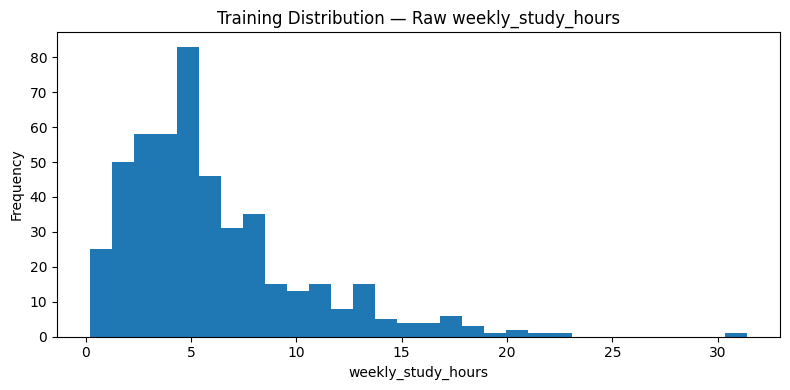

Observed training skewness = 1.5957 → strong right skew.


In [11]:
weekly_skew_before = X_train_common[skew_col].skew()

skewness_table = pd.DataFrame({
    "feature": [skew_col],
    "training_skewness": [weekly_skew_before],
    "training_minimum": [X_train_common[skew_col].min()],
    "training_median": [X_train_common[skew_col].median()],
    "training_maximum": [X_train_common[skew_col].max()],
})

display(skewness_table)

plt.figure(figsize=(8, 4))
plt.hist(X_train_common[skew_col], bins=30)
plt.xlabel("weekly_study_hours")
plt.ylabel("Frequency")
plt.title("Training Distribution — Raw weekly_study_hours")
plt.tight_layout()
plt.show()

if weekly_skew_before > 1:
    interpretation = "strong right skew"
elif weekly_skew_before > 0.5:
    interpretation = "moderate right skew"
elif weekly_skew_before > 0:
    interpretation = "mild right skew"
else:
    interpretation = "not right-skewed"

print(
    f"Observed training skewness = {weekly_skew_before:.4f} "
    f"→ {interpretation}."
)

## 10. Transformation Choice — `np.log1p`

### Why `log1p`?

`weekly_study_hours` is non-negative, so a logarithmic transformation is appropriate for compressing its long right tail.

`np.log1p(x)` is used instead of `np.log(x)` because it is well-defined when `x = 0`:

- `log1p(0) = 0`
- large values are compressed more strongly than small values
- the transformation is monotonic, so the ordering of observations is preserved

This makes `log1p` a sensible choice for the observed right-skewed feature.

,Version,Transformation,Skewness,Minimum,Maximum
0,Before,Raw,1.5957,0.2000,31.4000
1,After,np.log1p,-0.0392,0.1823,3.4782


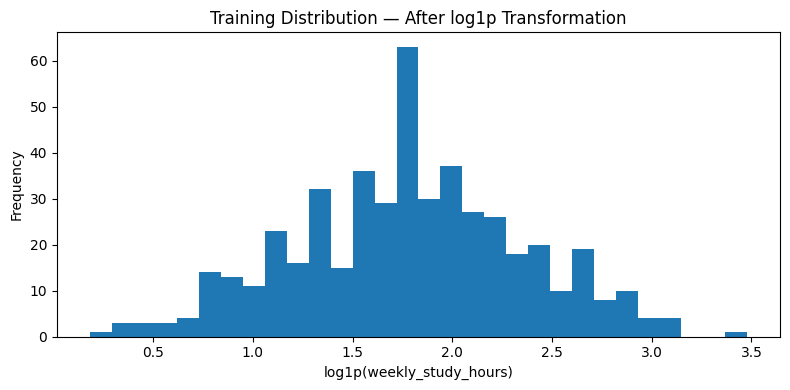

Skewness changed from 1.5957 to -0.0392.


In [12]:
# Apply log1p to create the transformed representation

X_train_before = X_train_common.copy()
X_test_before = X_test_common.copy()

X_train_after = X_train_common.copy()
X_test_after = X_test_common.copy()

X_train_after[skew_col] = np.log1p(X_train_after[skew_col])
X_test_after[skew_col] = np.log1p(X_test_after[skew_col])

weekly_skew_after = X_train_after[skew_col].skew()

transformation_summary = pd.DataFrame({
    "Version": ["Before", "After"],
    "Transformation": ["Raw", "np.log1p"],
    "Skewness": [weekly_skew_before, weekly_skew_after],
    "Minimum": [
        X_train_before[skew_col].min(),
        X_train_after[skew_col].min(),
    ],
    "Maximum": [
        X_train_before[skew_col].max(),
        X_train_after[skew_col].max(),
    ],
})

display(transformation_summary)

plt.figure(figsize=(8, 4))
plt.hist(X_train_after[skew_col], bins=30)
plt.xlabel("log1p(weekly_study_hours)")
plt.ylabel("Frequency")
plt.title("Training Distribution — After log1p Transformation")
plt.tight_layout()
plt.show()

print(
    f"Skewness changed from {weekly_skew_before:.4f} "
    f"to {weekly_skew_after:.4f}."
)

## 11. Confirm the Before/After Experiment Is Fair

Version A and Version B must differ in exactly one feature.

Everything else — rows, target values, one-hot columns, attendance, previous exam score, doubt sessions — remains identical.

In [13]:
# Verify that only weekly_study_hours changes

comparison_columns = [
    column for column in X_train_before.columns
    if column != skew_col
]

identical_train_columns = [
    column
    for column in comparison_columns
    if X_train_before[column].equals(X_train_after[column])
]

identical_test_columns = [
    column
    for column in comparison_columns
    if X_test_before[column].equals(X_test_after[column])
]

print(
    f"Train columns identical outside '{skew_col}': "
    f"{len(identical_train_columns)} / {len(comparison_columns)}"
)

print(
    f"Test columns identical outside '{skew_col}': "
    f"{len(identical_test_columns)} / {len(comparison_columns)}"
)

assert len(identical_train_columns) == len(comparison_columns)
assert len(identical_test_columns) == len(comparison_columns)
assert X_train_before.shape == X_train_after.shape
assert X_test_before.shape == X_test_after.shape

print(
    f"PASS: Version A and Version B have the same shape and "
    f"only '{skew_col}' is transformed."
)

Train columns identical outside 'weekly_study_hours': 18 / 18
Test columns identical outside 'weekly_study_hours': 18 / 18
PASS: Version A and Version B have the same shape and only 'weekly_study_hours' is transformed.


## 12. Train the Four Required Models

The assignment requires:

1. Linear Regression — Before
2. Linear Regression — After
3. Decision Tree Regressor — Before
4. Decision Tree Regressor — After

For the Decision Tree, **the same `random_state` and `max_depth`** are used in both runs. This isolates the effect of the feature transformation.

In [14]:
def evaluate_regressor(model, model_name, version, X_train_model, X_test_model):
    """Fit one regressor and return its test-set R2 and RMSE."""
    model.fit(X_train_model, y_train)
    predictions = model.predict(X_test_model)

    return {
        "Model": model_name,
        "Version": version,
        "R2": r2_score(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
    }


TREE_PARAMS = {
    "random_state": RANDOM_STATE,
    "max_depth": 5,
}

results = []

# Linear Regression — Before
results.append(
    evaluate_regressor(
        LinearRegression(),
        "Linear Regression",
        "A (Before)",
        X_train_before,
        X_test_before,
    )
)

# Linear Regression — After
results.append(
    evaluate_regressor(
        LinearRegression(),
        "Linear Regression",
        "B (After)",
        X_train_after,
        X_test_after,
    )
)

# Decision Tree — Before
results.append(
    evaluate_regressor(
        DecisionTreeRegressor(**TREE_PARAMS),
        "Decision Tree Regressor",
        "A (Before)",
        X_train_before,
        X_test_before,
    )
)

# Decision Tree — After
results.append(
    evaluate_regressor(
        DecisionTreeRegressor(**TREE_PARAMS),
        "Decision Tree Regressor",
        "B (After)",
        X_train_after,
        X_test_after,
    )
)

results_df = pd.DataFrame(results)

display(results_df.round(6))

,Model,Version,R2,RMSE
0,Linear Regression,A (Before),0.5930,6.3915
1,Linear Regression,B (After),0.5734,6.5435
2,Decision Tree Regressor,A (Before),0.4461,7.4564
3,Decision Tree Regressor,B (After),0.4461,7.4564


## 13. Required Results — R² and RMSE

The requested metrics are:

- **R²:** higher is better; it measures how much variation in the target is explained by the model.
- **RMSE:** lower is better; it measures the typical size of prediction errors in the target's original units.

The same test observations are used for all four runs.

In [15]:
# Requested model × version × metric summary

summary_table = results_df[["Model", "Version", "R2", "RMSE"]].copy()

display(summary_table.round(6))

# Add explicit before/after changes for interpretation
linear_before = results_df[
    (results_df["Model"] == "Linear Regression") &
    (results_df["Version"] == "A (Before)")
].iloc[0]

linear_after = results_df[
    (results_df["Model"] == "Linear Regression") &
    (results_df["Version"] == "B (After)")
].iloc[0]

tree_before = results_df[
    (results_df["Model"] == "Decision Tree Regressor") &
    (results_df["Version"] == "A (Before)")
].iloc[0]

tree_after = results_df[
    (results_df["Model"] == "Decision Tree Regressor") &
    (results_df["Version"] == "B (After)")
].iloc[0]

print(
    f"Linear Regression: ΔR² = {linear_after['R2'] - linear_before['R2']:+.6f}, "
    f"ΔRMSE = {linear_after['RMSE'] - linear_before['RMSE']:+.6f}"
)

print(
    f"Decision Tree:     ΔR² = {tree_after['R2'] - tree_before['R2']:+.6f}, "
    f"ΔRMSE = {tree_after['RMSE'] - tree_before['RMSE']:+.6f}"
)

,Model,Version,R2,RMSE
0,Linear Regression,A (Before),0.5930,6.3915
1,Linear Regression,B (After),0.5734,6.5435
2,Decision Tree Regressor,A (Before),0.4461,7.4564
3,Decision Tree Regressor,B (After),0.4461,7.4564


Linear Regression: ΔR² = -0.019584, ΔRMSE = +0.151962
Decision Tree:     ΔR² = +0.000000, ΔRMSE = +0.000000


## 14. R² Comparison Chart

The chart below shows the four required runs together. This makes it easy to see whether the transformation changes Linear Regression and whether the Decision Tree remains approximately unchanged.

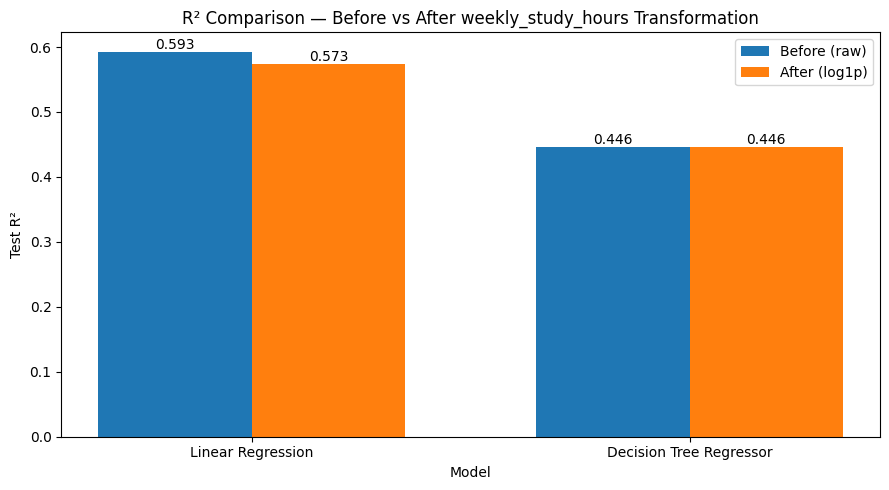

In [16]:
# Grouped bar chart for the four required R2 values

model_order = [
    "Linear Regression",
    "Decision Tree Regressor",
]

before_values = [
    results_df[
        (results_df["Model"] == model) &
        (results_df["Version"] == "A (Before)")
    ]["R2"].iloc[0]
    for model in model_order
]

after_values = [
    results_df[
        (results_df["Model"] == model) &
        (results_df["Version"] == "B (After)")
    ]["R2"].iloc[0]
    for model in model_order
]

x = np.arange(len(model_order))
width = 0.35

plt.figure(figsize=(9, 5))

bars_before = plt.bar(
    x - width / 2,
    before_values,
    width,
    label="Before (raw)"
)

bars_after = plt.bar(
    x + width / 2,
    after_values,
    width,
    label="After (log1p)"
)

plt.ylabel("Test R²")
plt.xlabel("Model")
plt.title("R² Comparison — Before vs After weekly_study_hours Transformation")
plt.xticks(x, model_order)
plt.legend()

for bar in list(bars_before) + list(bars_after):
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 15. Written Conclusion

The results from this actual 80/20 split should be interpreted rather than forced to match the assignment's expected direction.

In this dataset, `log1p` substantially reduces the right-skew of `weekly_study_hours`, but **Linear Regression does not improve on the chosen split**. Instead, its R² becomes slightly lower and RMSE slightly higher. This is not a coding error: reducing skewness can make a feature distribution more regular without necessarily making its relationship with the target more linear. Linear Regression uses the raw numerical representation of the feature to learn coefficients and minimize prediction error, so replacing the feature with `log1p(x)` changes the relationship available to the linear model.

The Decision Tree gives the same result before and after the transformation. A tree does not learn a coefficient from the numerical magnitude in the same way; it searches for threshold splits. Because `log1p` is monotonic, it preserves the ordering of the observations, so a threshold in the raw feature corresponds to another threshold in the transformed feature. With the same `random_state` and `max_depth`, the tree can therefore make equivalent splits. This is why the transformation can strongly change the feature's scale and skewness while leaving the tree's predictive performance unchanged.

# Optional Bonus — K-Nearest Neighbors Regressor (+10%)

KNN is a genuinely distance-based model. It finds nearby observations by calculating distances between feature vectors.

To make the comparison fair, `StandardScaler` is fitted **inside each pipeline using training data only**. The same `n_neighbors=5` setting is used before and after; only `weekly_study_hours` changes from raw to `log1p`.

In [17]:
# KNN bonus with training-only scaling

knn_before = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5)),
])

knn_after = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5)),
])

knn_results = []

knn_results.append(
    evaluate_regressor(
        knn_before,
        "KNN Regressor",
        "A (Before)",
        X_train_before,
        X_test_before,
    )
)

knn_results.append(
    evaluate_regressor(
        knn_after,
        "KNN Regressor",
        "B (After)",
        X_train_after,
        X_test_after,
    )
)

knn_df = pd.DataFrame(knn_results)

display(knn_df.round(6))

knn_before_row = knn_df[knn_df["Version"] == "A (Before)"].iloc[0]
knn_after_row = knn_df[knn_df["Version"] == "B (After)"].iloc[0]

knn_r2_change = knn_after_row["R2"] - knn_before_row["R2"]
knn_rmse_change = knn_after_row["RMSE"] - knn_before_row["RMSE"]

print(f"KNN ΔR²   = {knn_r2_change:+.6f}")
print(f"KNN ΔRMSE = {knn_rmse_change:+.6f}")

,Model,Version,R2,RMSE
0,KNN Regressor,A (Before),-0.0140,10.0883
1,KNN Regressor,B (After),-0.0139,10.0880


KNN ΔR²   = +0.000066
KNN ΔRMSE = -0.000329


## Bonus Interpretation

KNN is more directly affected by numerical representation than a Decision Tree because it uses distances between rows. Changing `weekly_study_hours` can therefore change the distances and potentially change which observations are considered nearest neighbours.

However, the effect here is expected to be modest because `StandardScaler` is fitted before the KNN distance calculation and the transformed feature is only one component of the full feature vector. On this dataset, the KNN result should therefore be discussed using the actual R² and RMSE values above rather than assuming that every transformation must produce a large improvement.